In [41]:
#import necessary libraries

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [3]:
#loading dataset
df = pd.read_csv("sales_data.csv")
df.head()

,product_id,brand,category,price,quantity_sold,total_revenue
0,P1000,BrandC,Clothing,190.40,51,9710.40
1,P1001,BrandB,Clothing,475.60,7,3329.20
2,P1002,BrandD,Toys,367.34,21,7714.14
3,P1003,BrandD,Home,301.34,73,21997.82
4,P1004,BrandB,Clothing,82.23,39,3206.97


In [5]:
#establishing connetion
conn = sqlite3.connect('sales_data.db')

In [7]:
# create a db file
df.to_sql("sales_data", conn, if_exists="replace", index=False)

30

In [11]:
# excecuting query to check data

query = '''SELECT * FROM sales_data'''

In [13]:
df1=pd.read_sql_query(query, conn)
df1.head()

,product_id,brand,category,price,quantity_sold,total_revenue
0,P1000,BrandC,Clothing,190.40,51,9710.40
1,P1001,BrandB,Clothing,475.60,7,3329.20
2,P1002,BrandD,Toys,367.34,21,7714.14
3,P1003,BrandD,Home,301.34,73,21997.82
4,P1004,BrandB,Clothing,82.23,39,3206.97


In [45]:
#executing the query
query = '''SELECT brand, sum(quantity_sold) AS total_qty, SUM(total_revenue) AS revenue FROM sales_data GROUP BY brand'''

In [47]:
df2=pd.read_sql_query(query,conn)
print(df2)

    brand  total_qty   revenue
0  BrandA        280  78507.98
1  BrandB        397  95975.33
2  BrandC        154  37595.71
3  BrandD        451  95147.96


<Axes: xlabel='brand'>

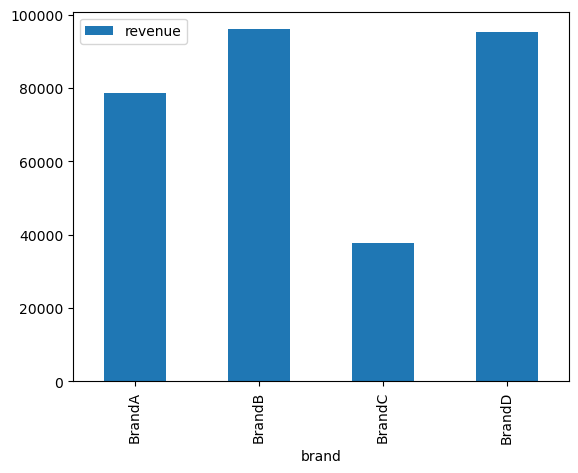

In [49]:
#plot of bar chart
df2.plot(kind='bar',x='brand',y='revenue')